<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/Trainers_notes/Machine_Learning/NaiveBayes_Aisha(23_09).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Naive Bayes
- supervised learning classification algorithm,which is based on Bayes theorem and used for solving classification problem.
- It predicts the category or class of data based on probabilities.
- **Naive Bayes** predicts how likely something is, based on the evidence(features) you give it.


#Why is it called Naive?
- Its called **Naive** because it assumes all the features(input) are independent of each other, which is rarely true in real life.

#What is it used for?
- Text classification(Spam and Non-Spam classification)
- Sentiment Analysis(Postive or negative review)
- Medical Diagnosis(Flu or not)
- Email Filtering
- Face Recognition(in basic version)

- **P(A|B) : Probability of A occuring given that B has occured**
- **P(B|A) : Probability of B occuring given that A has occured**
- **P(A) : Probability of A occuring**
- **P(B) : Probability of B occuring**

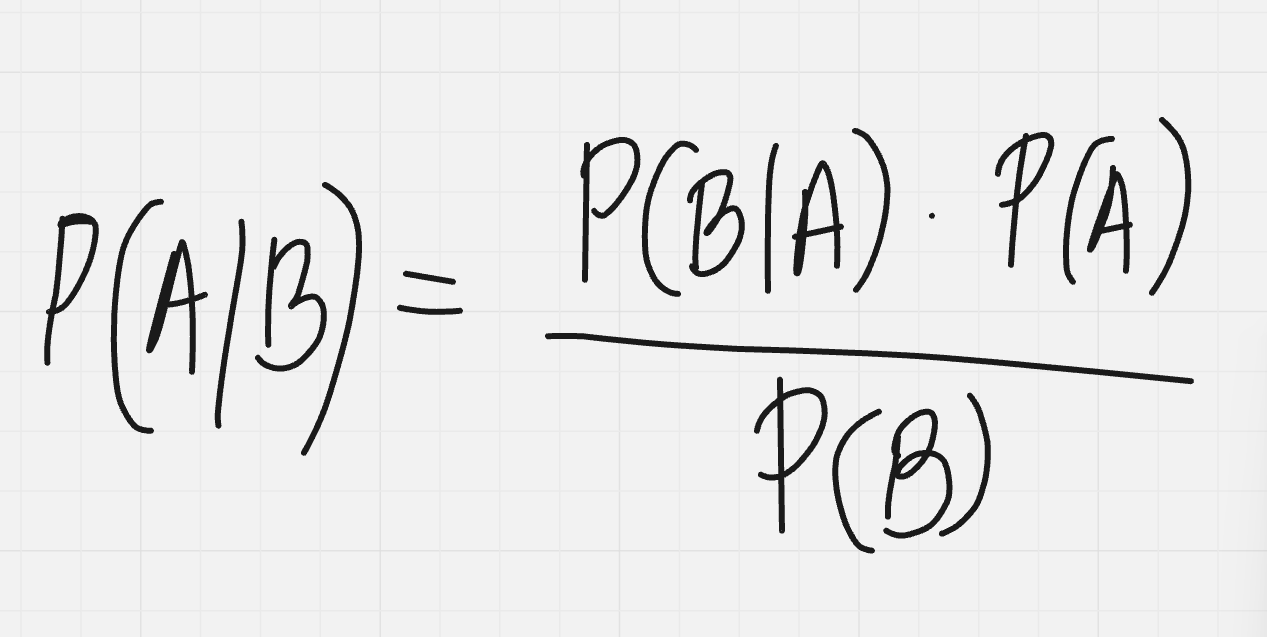

In [ ]:
#dataset https://drive.google.com/file/d/1NKga1LKy5wVu6UExyTkXYEaZHOw6hHIP/view?usp=sharing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/heart.csv")

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

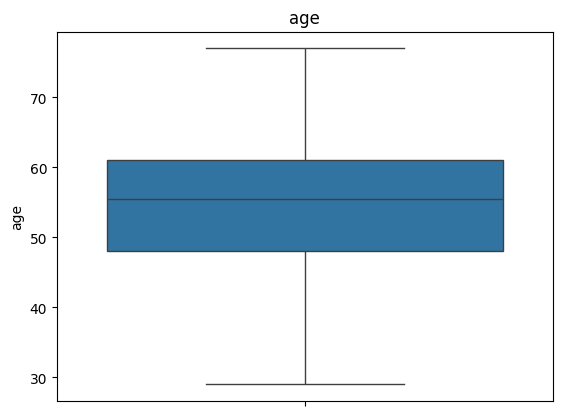

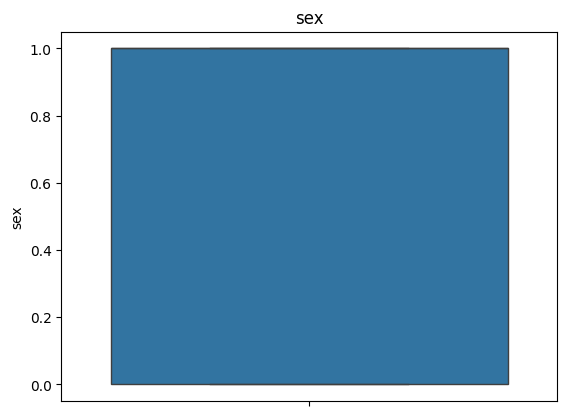

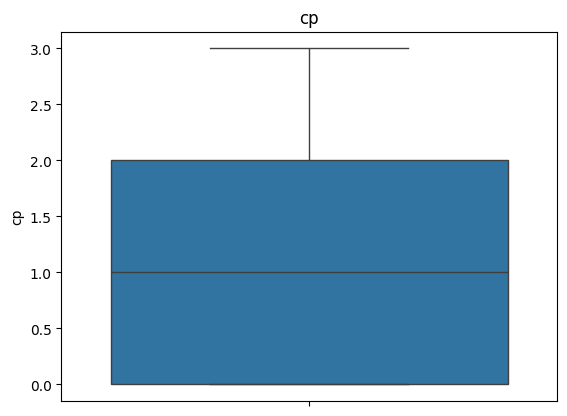

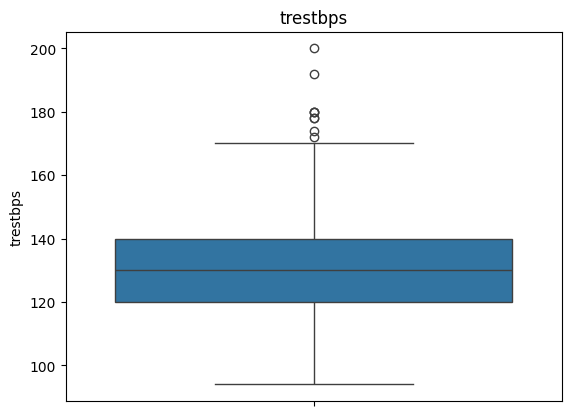

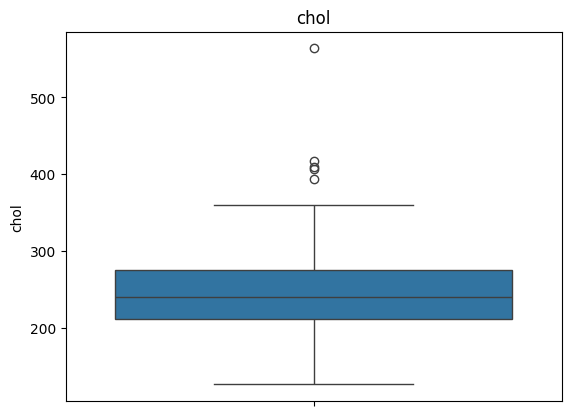

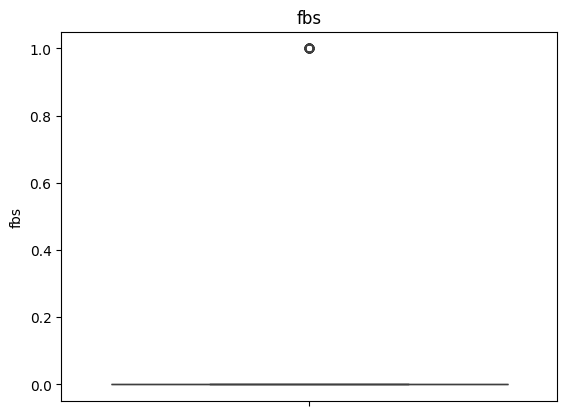

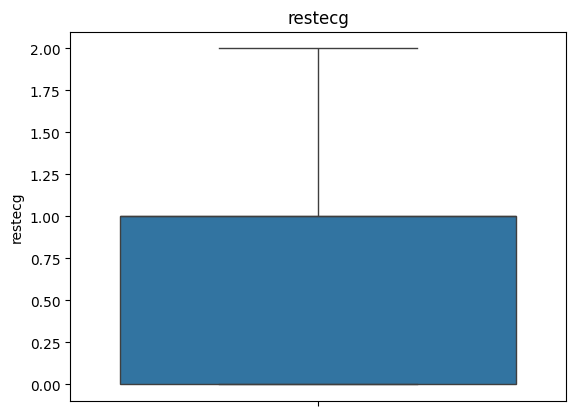

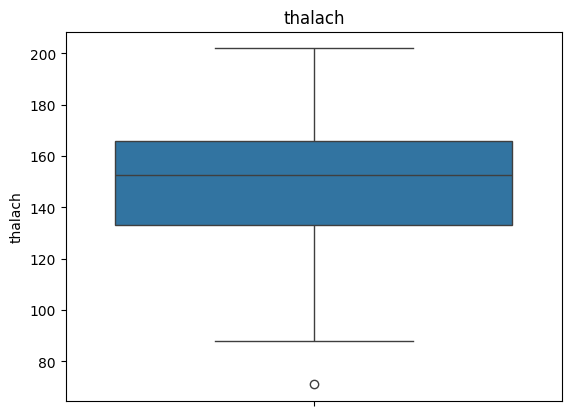

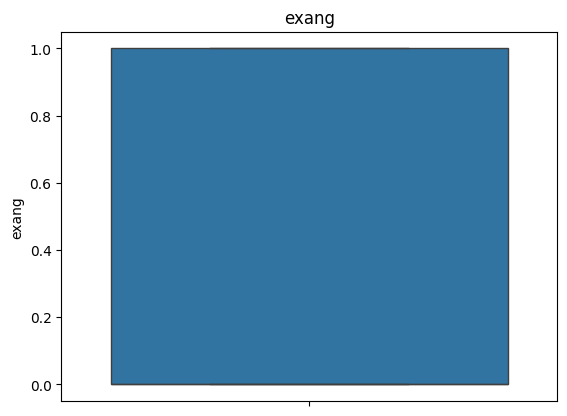

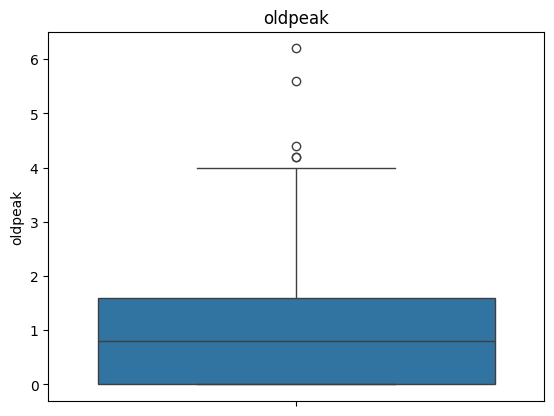

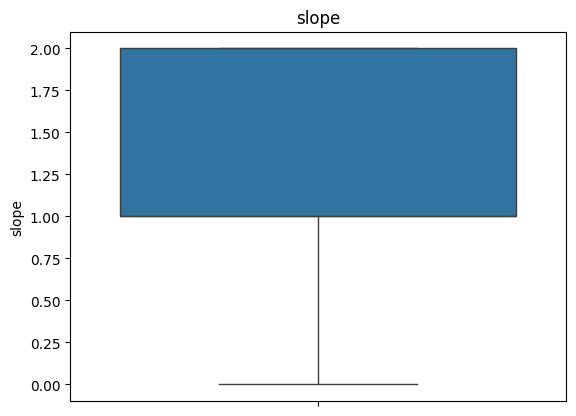

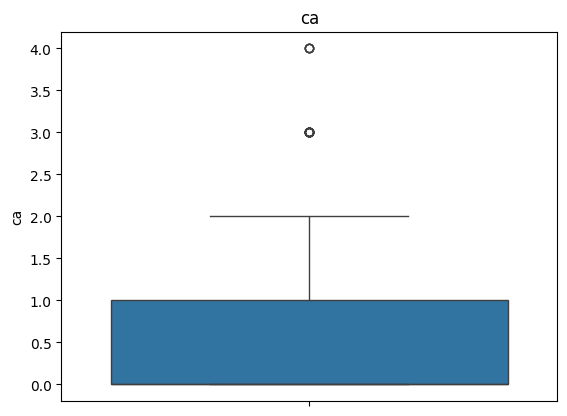

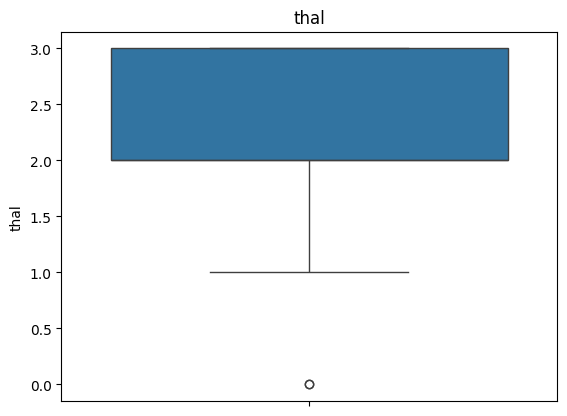

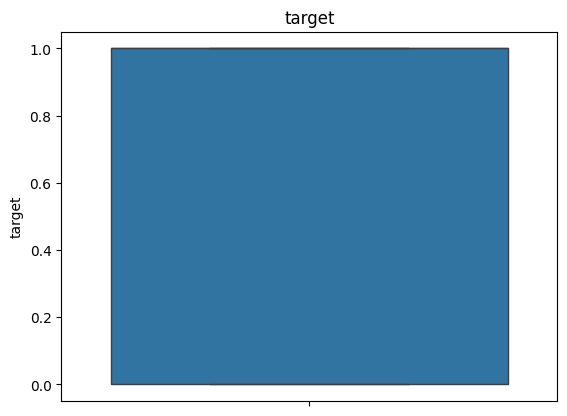

In [ ]:
#outlier removal avoided since the dataset is medical

for col in df.columns:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [ ]:
#no label encoding required.

In [ ]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


<Axes: >

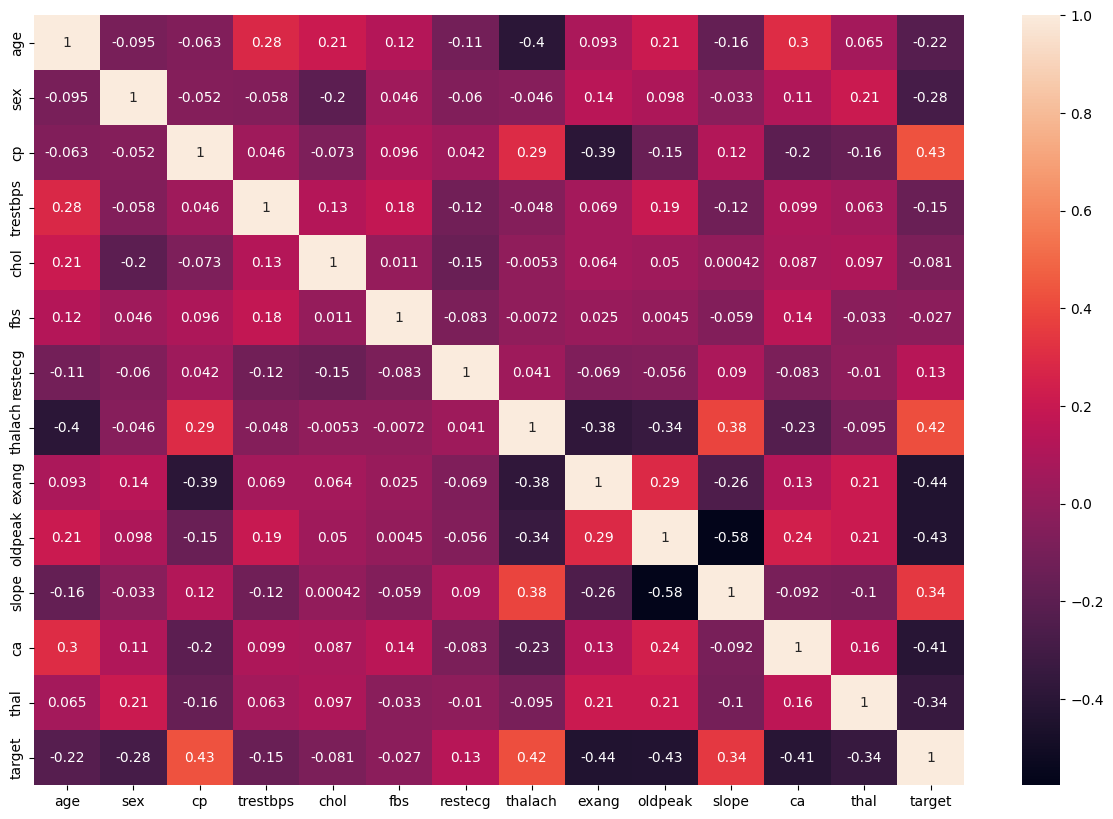

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

#TYPES OF NAIVE BAYES:
1. Gaussian Naive Bayes
  - For continuous numeric data
  - assume features follow a normal/gaussian distribution.
  - **Example** : Predicting disease on: BP, Body Temperature, Heart Rate

2. Multinomial Naive Bayes
  - For count data(discrete values)
  - Perfect for NLP tasks
  - Often used for text classification
  - **Example** : Spam Detection: counting words like "free", "win", "disappear"

3. Bernoulli Naive Bayes
  - For binary/boolean features(0 or 1)
  - Features are present/absent, yes/no, true/false
  - works with text data, but works on whether the word appears or not
  - **Example** : Spam detection: whether mail has win or not

4. Categorical Naive Bayes
  - Categorical features(non-numeric, non-ordered categories)
  - **Example**: Predicting pet insurance claim:
      - Animal type = cat/dog
      - Breed = Labrador/ Husky
      - Indoor/Outdoor = Yes/ No

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
#splitting the data into x and y axis
x=df.drop('target',axis=1)
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [ ]:
y=df['target']
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
#Splitting the data into training and testing

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [ ]:
y_train

,target
132,1
203,0
197,0
75,1
177,0
...,...
189,0
71,1
106,1
271,0


In [ ]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,55,1,0,132,353,0,1,132,1,1.2,1,1,3
229,64,1,2,125,309,0,1,131,1,1.8,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,51,1,0,140,298,0,1,122,1,4.2,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2


In [ ]:
y_test

,target
180,0
229,0
111,1
247,0
60,1
...,...
250,0
104,1
300,0
194,0


In [ ]:
from sklearn.naive_bayes import * #import all
from sklearn.metrics import *

In [ ]:
#GaussianNB

model1=GaussianNB()
model1.fit(x_train,y_train)
y_pred=model1.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8852459016393442


In [ ]:
confusion_matrix(y_test,y_pred)

array([[27,  2],
       [ 5, 27]])

In [ ]:
#MultinomialNB

model2=MultinomialNB()
model2.fit(x_train,y_train)
y_pred=model2.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.819672131147541


In [ ]:
confusion_matrix(y_test,y_pred)

array([[24,  5],
       [ 6, 26]])

In [ ]:
#BernoulliNB

model3=BernoulliNB()
model3.fit(x_train,y_train)
y_pred=model3.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8688524590163934


In [ ]:
confusion_matrix(y_test,y_pred)

array([[25,  4],
       [ 4, 28]])

In [ ]:
#CategoricalNB

model4=CategoricalNB()
model4.fit(x_train,y_train)
y_pred=model4.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8524590163934426


In [ ]:
confusion_matrix(y_test,y_pred)

array([[24,  5],
       [ 4, 28]])

In [ ]:
#DECISION TREE------------------

In [ ]:
from sklearn.tree import DecisionTreeClassifier

m=DecisionTreeClassifier()

m.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=m.predict(x_test)

In [ ]:
accuracy_score(y_pred,y_test)

0.819672131147541

In [ ]:
#max_depth =  1-15
depth=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]

In [ ]:
for max_d in depth:
  model=DecisionTreeClassifier(max_depth=max_d,random_state=58)
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_pred,y_test)
  print(f"Accuray for the model for depth {max_d} is {acc}")

Accuray for the model for depth 1 is 0.7213114754098361
Accuray for the model for depth 2 is 0.7377049180327869
Accuray for the model for depth 3 is 0.7868852459016393
Accuray for the model for depth 4 is 0.8032786885245902
Accuray for the model for depth 5 is 0.8032786885245902
Accuray for the model for depth 6 is 0.7868852459016393
Accuray for the model for depth 7 is 0.7377049180327869
Accuray for the model for depth 8 is 0.7868852459016393
Accuray for the model for depth 9 is 0.7868852459016393
Accuray for the model for depth 10 is 0.7704918032786885
Accuray for the model for depth 11 is 0.7704918032786885
Accuray for the model for depth 12 is 0.7704918032786885
Accuray for the model for depth 13 is 0.7704918032786885
Accuray for the model for depth 14 is 0.7704918032786885
Accuray for the model for depth 15 is 0.7704918032786885


In [ ]:
final_model=DecisionTreeClassifier(max_depth=4,random_state=58)
final_model.fit(x_train,y_train)
y_pred=final_model.predict(x_test)
print(accuracy_score(y_pred,y_test))

0.8032786885245902


In [ ]:
param_grid={
    "criterion":['gini','entropy'],
    'splitter':['best','random'],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    "max_features":[None,'sqrt','log2']
}

In [ ]:
#if dataset has 100 features:
#None: all 100 features
#sqrt: use only 10 at each split
#log2: uses ~7 features

In [ ]:
from sklearn.model_selection import GridSearchCV
dt=DecisionTreeClassifier(random_state=58)

grid_search=GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=58),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [ ]:
best_params=grid_search.best_params_

In [ ]:
best_params

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'splitter': 'random'}

In [ ]:
final_model=DecisionTreeClassifier(criterion = 'entropy',
                                   max_depth = 5,
                                   max_features = 'sqrt',
                                   min_samples_leaf = 4,
                                   min_samples_split= 2,
                                   splitter= 'random',
                                   random_state=58
)

In [ ]:
final_model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features='sqrt',
                       min_samples_leaf=4, random_state=58, splitter='random')

In [ ]:
y_pred=final_model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8032786885245902
